# **Digital Assignment 2**
## **Subject: Deep Learning Lab (PMDS603P)**
## **Name: Soumyadeep Ganguly**
## **Reg No: 24MDT0082**

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from keras.regularizers import l2
import tensorflow as tf

# **Question 1**

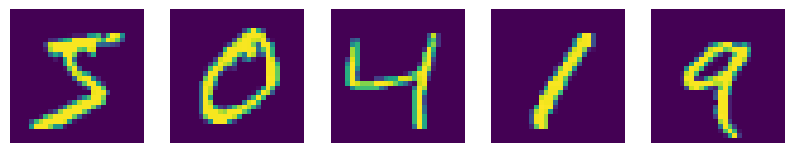

In [2]:
batch_size = 128
num_classes = 10
epochs = 10
(X_train, y_train), (X_test, y_test) = mnist.load_data()
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axs[i].imshow(X_train[i])
    axs[i].axis('off')    


plt.show()

In [3]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255


y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [4]:
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation = 'softmax'))
model.summary()

e:\VIT Study Materials\SEM 3\Deep Learning\LAB\.venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='CategoricalCrossentropy', optimizer=SGD(), metrics=['accuracy'])
hist = model.fit(X_train, y_train_cat, batch_size=64, epochs=100,verbose=1, validation_data=(X_test, y_test_cat))

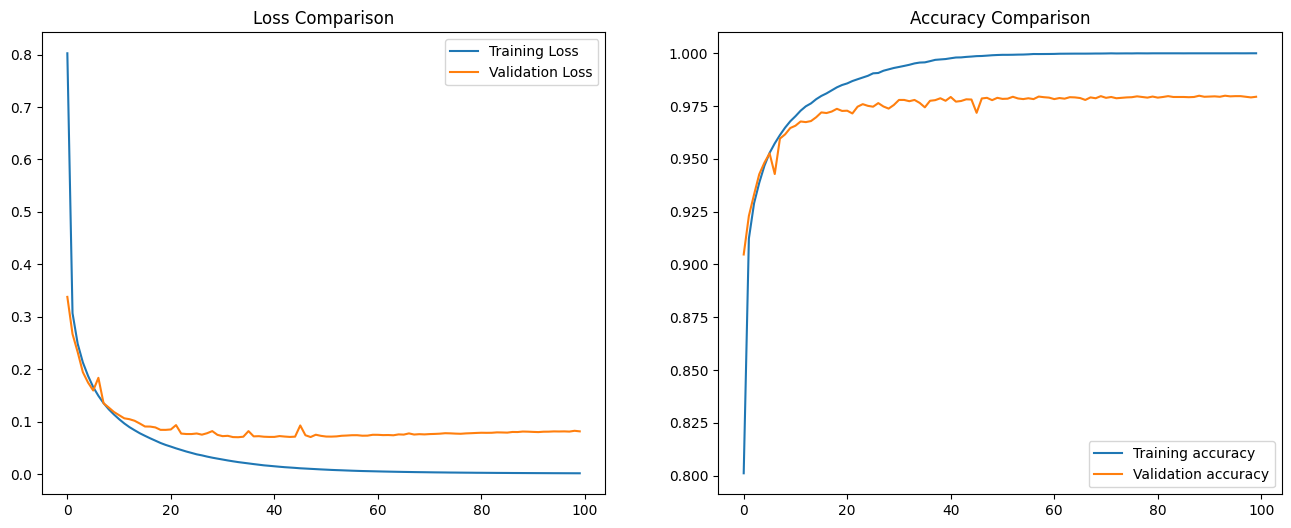

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(hist.history['loss'], label='Training Loss')
axs[0].plot(hist.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(hist.history['accuracy'], label='Training accuracy')
axs[1].plot(hist.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()

In [8]:
print("="*18)
print("Model Performance")
print("="*18)
loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"loss={loss:.4f}, acc={acc:.4f}")

Model Performance
loss=0.0815, acc=0.9794


In [9]:
predictions = model.predict(X_test)
for i in range(5):
    predicted_class = np.argmax(predictions[i])
    true_class = np.argmax(y_test_cat[i])
    print(f"Image {i+1}: Predicted = {predicted_class}, True = {true_class}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Image 1: Predicted = 7, True = 7
Image 2: Predicted = 2, True = 2
Image 3: Predicted = 1, True = 1
Image 4: Predicted = 0, True = 0
Image 5: Predicted = 4, True = 4


## **Model 2**

In [11]:
model2 = Sequential()
model2.add(Dense(512, activation="relu", input_shape=(784,)))
model2.add(Dense(256, activation="sigmoid"))
model2.add(Dropout(0.3)) 
model2.add(Dense(128, activation="sigmoid"))
model2.add(Dropout(0.2))
model2.add(Dense(10, activation="softmax"))
model2.summary()

e:\VIT Study Materials\SEM 3\Deep Learning\LAB\.venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
X_subtrain, X_valid, y_subtrain, y_valid = train_test_split(X_train, y_train, test_size=0.1, random_state=1)
y_subtrain_cat = tf.keras.utils.to_categorical(y_subtrain, num_classes=10)
y_valid_cat = tf.keras.utils.to_categorical(y_valid, num_classes=10)


In [14]:
estop = EarlyStopping(monitor = 'val_loss', min_delta = 1e-5, mode= 'min', patience=4, verbose = 1, restore_best_weights=True)

In [15]:
sgd = SGD(learning_rate = 0.01)

In [ ]:
model2.compile(loss='CategoricalCrossentropy', optimizer=sgd, metrics=['accuracy'])
hist2 = model2.fit(X_subtrain, y_subtrain_cat, batch_size = 128, epochs=100, verbose = 1, validation_data = (X_valid, y_valid_cat), callbacks=[estop])

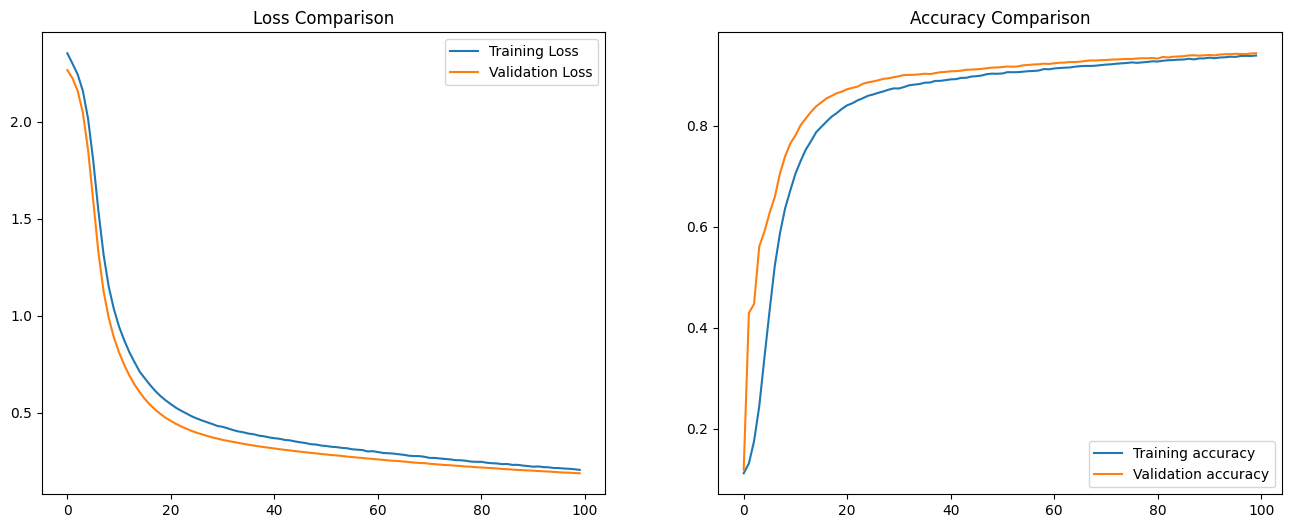

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(hist2.history['loss'], label='Training Loss')
axs[0].plot(hist2.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(hist2.history['accuracy'], label='Training accuracy')
axs[1].plot(hist2.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()

In [ ]:
print("="*18)
print("Model Performance")
print("="*18)
loss, acc = model2.evaluate(X_test, y_test_cat, verbose=0)
print(f"loss={loss:.4f}, acc={acc:.4f}")

Model Performance
loss=0.1762, acc=0.9472


In [19]:
predictions = model2.predict(X_test)
for i in range(5):
    predicted_class = np.argmax(predictions[i]) 
    true_class = np.argmax(y_test_cat[i])
    print(f"Image {i+1}: Predicted = {predicted_class}, True = {true_class}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Image 1: Predicted = 7, True = 7
Image 2: Predicted = 2, True = 2
Image 3: Predicted = 1, True = 1
Image 4: Predicted = 0, True = 0
Image 5: Predicted = 4, True = 4


## **Challenging Question**

In [20]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.weights_input_hidden = np.random.randn(input_size, hidden_size)
        self.weights_hidden_output = np.random.randn(hidden_size, output_size)
        self.bias_hidden = np.zeros((1, hidden_size))
        self.bias_output = np.zeros((1, output_size))
        
    def forwardpass(self, X):
        self.hidden_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
        self.hidden_output = sigmoid(self.hidden_input)

        self.final_input = np.dot(self.hidden_output, self.weights_hidden_output) + self.bias_output
        self.output = sigmoid(self.final_input)
        
        return self.output

    def backwardpass(self, X, y, output, learning_rate):
        error = y - output
        d_output = error * sigmoid_derivative(output)

        error_hidden = d_output.dot(self.weights_hidden_output.T)
        d_hidden = error_hidden * sigmoid_derivative(self.hidden_output)

        self.weights_hidden_output += self.hidden_output.T.dot(d_output) * learning_rate
        self.bias_output += np.sum(d_output, axis=0, keepdims=True) * learning_rate

        self.weights_input_hidden += X.T.dot(d_hidden) * learning_rate
        self.bias_hidden += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

    def train(self, X, y, epochs, learning_rate):
        for epoch in range(epochs):
            output = self.forwardpass(X)
            self.backwardpass(X, y, output, learning_rate)

            if epoch % 1000 == 0:
                loss = np.mean(0.5 * (y - output) ** 2)
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

In [21]:
X = np.array([[0, 0, 1],
              [0, 1, 1],
              [1, 0, 1],
              [1, 1, 1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

In [22]:
nn = NeuralNetwork(input_size=3, hidden_size=4, output_size=1)

In [23]:
nn.train(X, y, epochs=10000, learning_rate=0.1)

Epoch 0, Loss: 0.1425
Epoch 1000, Loss: 0.1177
Epoch 2000, Loss: 0.0834
Epoch 3000, Loss: 0.0342
Epoch 4000, Loss: 0.0123
Epoch 5000, Loss: 0.0062
Epoch 6000, Loss: 0.0038
Epoch 7000, Loss: 0.0027
Epoch 8000, Loss: 0.0021
Epoch 9000, Loss: 0.0016


In [24]:
print("\nFinal predictions:")
print(nn.forwardpass(X))


Final predictions:
[[0.02776603]
 [0.94780627]
 [0.9526893 ]
 [0.07184561]]


In [25]:
classified_output = (nn.forwardpass(X) > 0.5).astype(int)
print("\nClassified Output after training (0 or 1):")
print(classified_output)



Classified Output after training (0 or 1):
[[0]
 [1]
 [1]
 [0]]


# **Question 2**

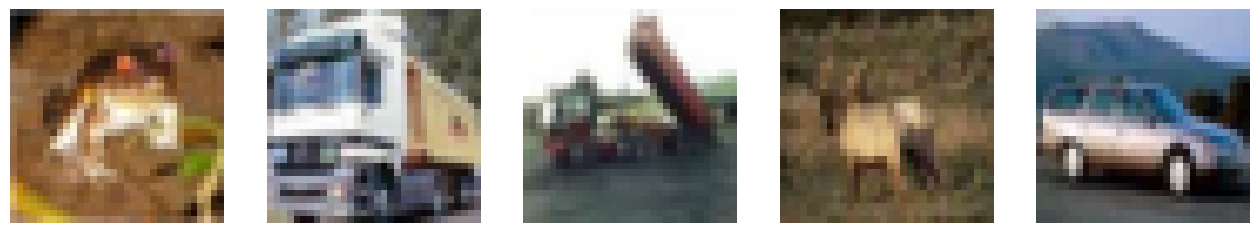

In [34]:
batch_size = 128
num_classes = 10
epochs = 10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
fig, axs = plt.subplots(1, 5, figsize=(16, 4))
for i in range(5):
    axs[i].imshow(X_train[i])
    axs[i].axis('off')    


plt.show()

In [35]:
X_train = X_train.reshape(50000, 3072)
X_test = X_test.reshape(10000, 3072)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=10)
print(f'{X_train.shape}----{X_test.shape} ||| {y_train_cat.shape}----{y_test_cat.shape}')

(50000, 3072)----(10000, 3072) ||| (50000, 10)----(10000, 10)


In [32]:
estop = EarlyStopping(monitor = 'val_loss', min_delta = 1e-5, mode= 'min', patience=4, verbose = 1, restore_best_weights=True)

(50000, 3072)----(10000, 3072) ||| (50000, 10)----(10000, 10)


In [43]:
model3 = Sequential()
model3.add(Dense(256, activation='relu', input_shape=(3072,)))
model3.add(Dropout(0.3))
model3.add(Dense(256, activation='relu'))
model3.add(Dropout(0.2))
model3.add(Dense(128, activation='relu'))
model3.add(Dense(10, activation="softmax"))
model3.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 886,666 (3.38 MB)

 Trainable params: 886,666 (3.38 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
estop2 = EarlyStopping(monitor = 'val_loss', min_delta = 1e-4, mode= 'min', patience=4, verbose = 1, restore_best_weights=True)

In [ ]:
model3.compile(loss='CategoricalCrossentropy', optimizer=SGD(learning_rate=0.001), metrics=['accuracy'])
hist3 = model3.fit(X_train, y_train_cat, verbose=1, batch_size=32, epochs=100, validation_data=(X_test, y_test_cat), callbacks=[estop2])


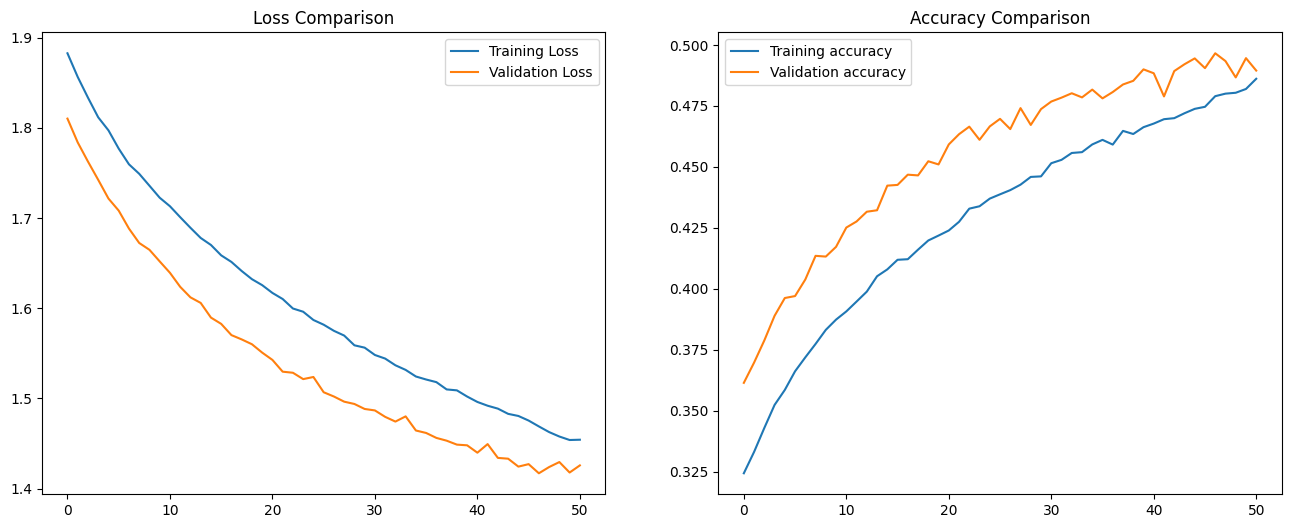

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(hist3.history['loss'], label='Training Loss')
axs[0].plot(hist3.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(hist3.history['accuracy'], label='Training accuracy')
axs[1].plot(hist3.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()

In [48]:
print("="*18)
print("Model Performance")
print("="*18)
loss, acc = model3.evaluate(X_test, y_test_cat, verbose=0)
print(f"loss={loss:.4f}, acc={acc:.4f}")

Model Performance
loss=1.4169, acc=0.4966


# **Question 3**

In [51]:
model4 = Sequential()
model4.add(Dense(256, activation='relu', input_shape=(3072,)))
model4.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
model4.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model4.add(Dense(10, activation='softmax'))
model4.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 886,666 (3.38 MB)

 Trainable params: 886,666 (3.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model4.compile(loss='CategoricalCrossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])
hist4 = model4.fit(X_train, y_train_cat, verbose=1, batch_size=64, epochs=10, validation_data=(X_test, y_test_cat))


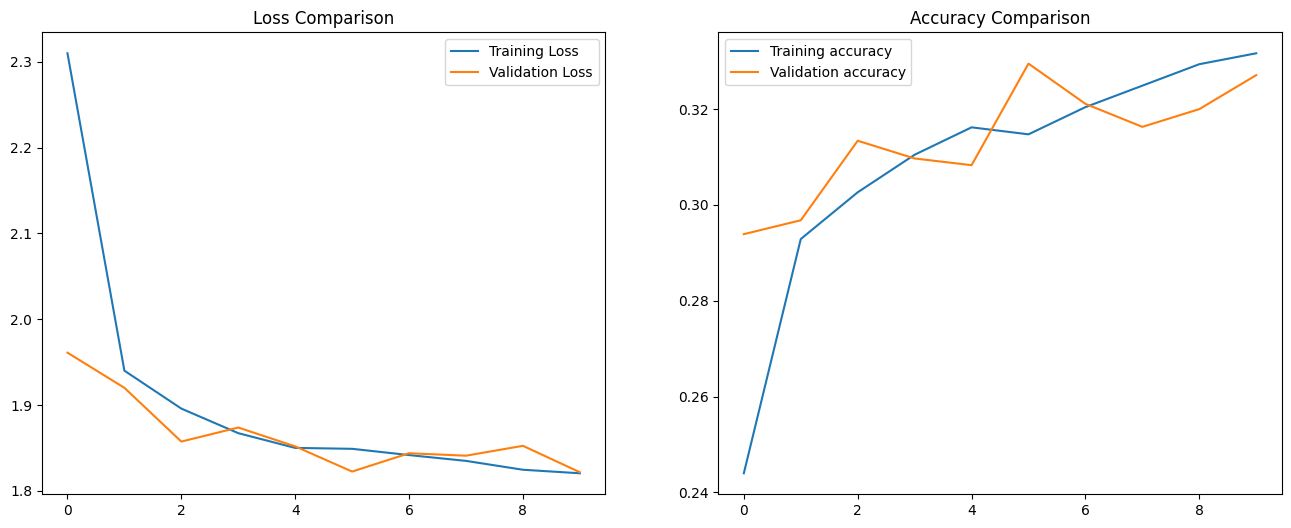

In [54]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(hist4.history['loss'], label='Training Loss')
axs[0].plot(hist4.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(hist4.history['accuracy'], label='Training accuracy')
axs[1].plot(hist4.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()

In [55]:
print("="*18)
print("Model Performance")
print("="*18)
loss, acc = model4.evaluate(X_test, y_test_cat, verbose=0)
print(f"loss={loss:.4f}, acc={acc:.4f}")

Model Performance
loss=1.8217, acc=0.3271


# **Question 4**

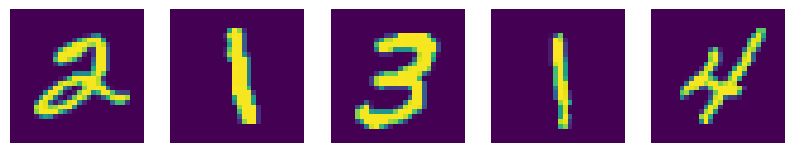

In [77]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axs[i].imshow(X_train[i+5])
    axs[i].axis('off')    


plt.show()

In [78]:
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [87]:
from tensorflow.keras import regularizers
def build_model(hp):
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))
    
    units = hp.Int('units', min_value=64, max_value=512, step=64)
    model.add(Dense(units, activation='relu'))
    
    dropout_rate = hp.Float('dropout', min_value=0.0, max_value=0.5, step=0.1)
    model.add(Dropout(dropout_rate))

    l2_reg = hp.Float('l2_reg', min_value=1e-5, max_value=1e-2, sampling='LOG')

    model.add(Dense(10, activation='softmax', kernel_regularizer=regularizers.l2(l2_reg)))

    model.compile(
        optimizer=SGD(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [91]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='mnist_tuning',
    project_name="dense_dropout_tune"
)

tuner.search(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=128,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)]
)

Reloading Tuner from mnist_tuning\dense_dropout_tune\tuner0.json


In [96]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print('Best Units: ', best_hps.get('units'))
print('Best Dropout: ', best_hps.get('dropout'))
print('Best l2_reg: ', best_hps.get('l2_reg'))

Best Units:  192
Best Dropout:  0.0
Best l2_reg:  1e-05


In [93]:
best_model = tuner.hypermodel.build(best_hps)

### Model Training with Best Parameters

In [ ]:
history = best_model.fit(X_train, y_train, 
                         validation_data=(X_test, y_test),
                         epochs=50) 

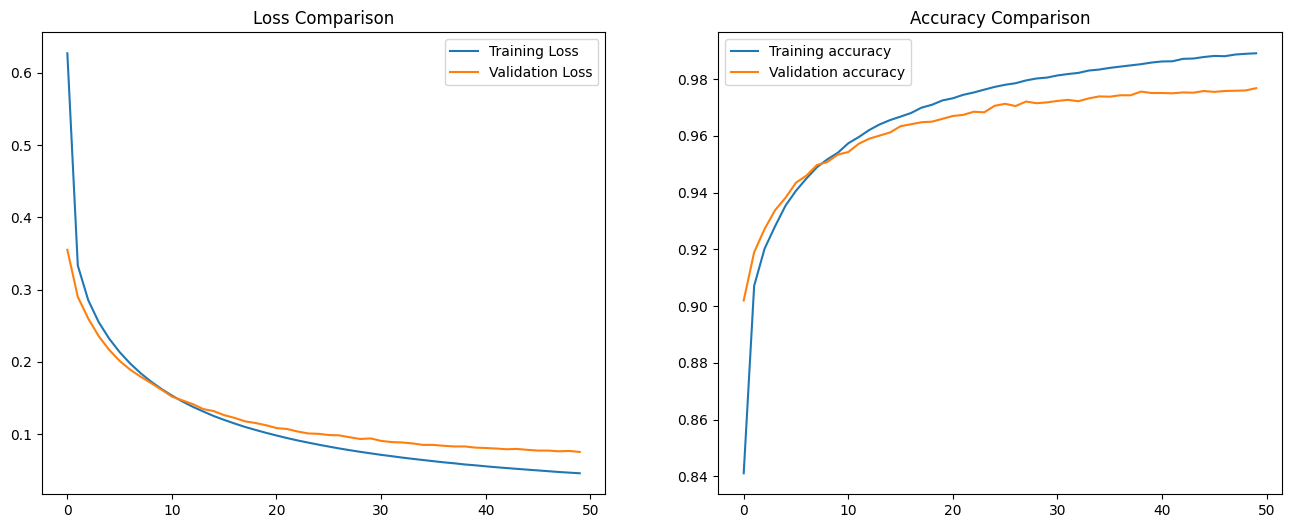

In [97]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(history.history['loss'], label='Training Loss')
axs[0].plot(history.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(history.history['accuracy'], label='Training accuracy')
axs[1].plot(history.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()

In [98]:
print("="*18)
print("Model Performance")
print("="*18)
loss, acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"loss={loss:.4f}, acc={acc:.4f}")

Model Performance
loss=0.0753, acc=0.9768


### Hyperparameter tuning on cifar10

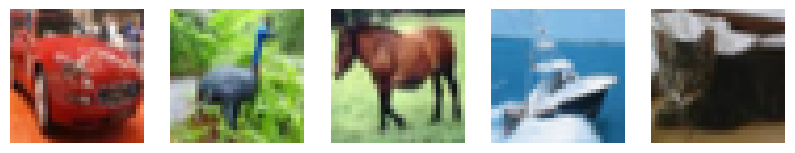

In [144]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axs[i].imshow(X_train[i+5])
    axs[i].axis('off')    


In [145]:
X_train = X_train.reshape(50000, 3072)
X_test = X_test.reshape(10000, 3072)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255.0
X_test /= 255.0
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [146]:
def build_cifar10_model(hp):
    model = Sequential()

    model.add(Flatten(input_shape=(3072,)))

    units = hp.Int('units', min_value=64, max_value=512, step=64)
    model.add(Dense(units, activation='relu'))

    dropout_rate = hp.Float('dropout', min_value=0.0, max_value=0.5, step=0.1)
    model.add(Dropout(dropout_rate))

    l2_reg = hp.Float('l2_reg', min_value=1e-5, max_value=1e-2, sampling='log')

    model.add(Dense(10, activation='softmax',
                    kernel_regularizer=regularizers.l2(l2_reg)))

    learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=SGD(learning_rate=learning_rate, momentum=0.9),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [147]:
tuner_cifar10 = kt.RandomSearch(
    build_cifar10_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='cifar10_tuning',
    project_name="dense_dropout_reg_cifar10_tune",
    max_consecutive_failed_trials=12   # default is 3
)

tuner_cifar10.search(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=128,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)]
)

Reloading Tuner from cifar10_tuning\dense_dropout_reg_cifar10_tune\tuner0.json


In [148]:
best_hps_cifar_10 = tuner_cifar10.get_best_hyperparameters(num_trials=1)[0]
print('Best Units: ', best_hps_cifar_10.get('units'))
print('Best Dropout: ', best_hps_cifar_10.get('dropout'))
print('Best l2_reg: ', best_hps_cifar_10.get('l2_reg'))

Best Units:  192
Best Dropout:  0.30000000000000004
Best l2_reg:  0.0006438822956658336


In [149]:
best_model_cifar10 = tuner_cifar10.hypermodel.build(best_hps_cifar_10)

In [ ]:

history_cifar10 = best_model_cifar10.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=128
)

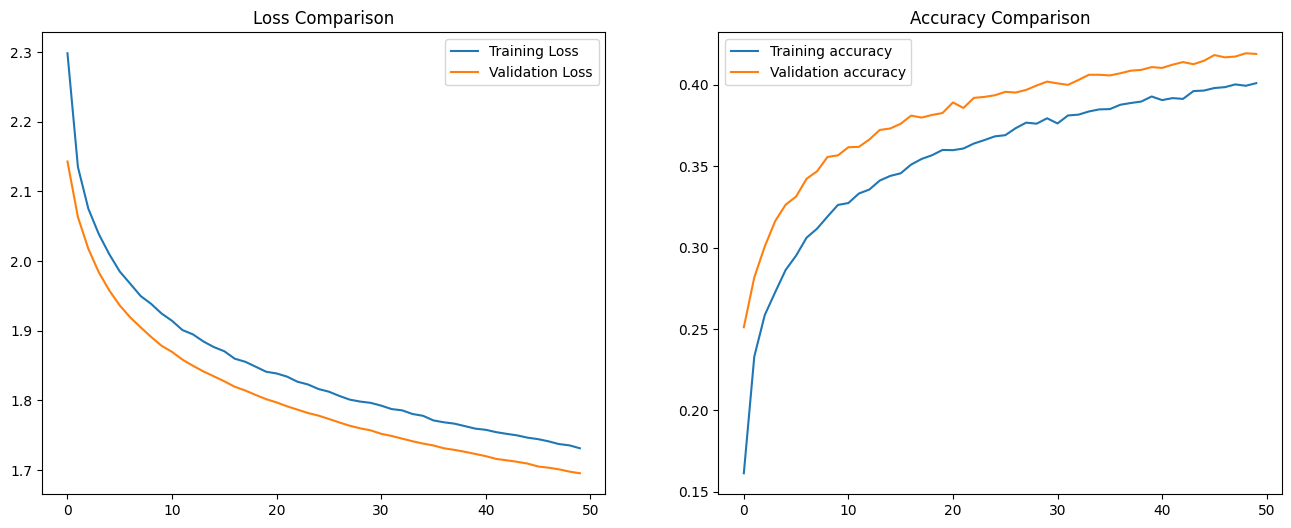

In [151]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(history_cifar10.history['loss'], label='Training Loss')
axs[0].plot(history_cifar10.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(history_cifar10.history['accuracy'], label='Training accuracy')
axs[1].plot(history_cifar10.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()

In [153]:
print("="*18)
print("Model Performance")
print("="*18)
loss, acc = best_model_cifar10.evaluate(X_test, y_test, verbose=0)
print(f"loss={loss:.4f}, acc={acc:.4f}")

Model Performance
loss=1.6955, acc=0.4190
